# Import Libraries

In [245]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import rc_context
import skimage
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

In [246]:
sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor="white", color_map='plasma')

scanpy==1.10.1 anndata==0.10.8 umap==0.5.5 numpy==1.26.4 scipy==1.11.4 pandas==1.5.3 scikit-learn==1.2.2 statsmodels==0.14.0 igraph==0.11.8 pynndescent==0.5.11


# Loading data

Create a file h5ad where the Adata Object will be saved.

In [247]:
results_file = "/YourProjectFolder/processed_scRNAseqDBC.h5ad"  # the file that will store the analysis results


Generate the raw count matrix.

In [248]:
adata = sc.read_10x_mtx(
    "/YourProjectFolder/filtered_feature_bc_matrix",  # the directory with the `.mtx` file
    var_names="gene_symbols",  # use gene symbols for the variable names (variables-axis index)
    cache=True,  # write a cache file for faster subsequent reading
)

... reading from cache file cache\C-Users-vaner-Desktop-DESF-Maggiolini-Anthem-filtered_feature_bc_matrix-matrix.h5ad


In [249]:
adata

AnnData object with n_obs × n_vars = 6336 × 33538
    var: 'gene_ids', 'feature_types'

Save the raw count matrix as an Adata object.

In [250]:
# Save to an HDF5 file
adata.write("raw_count_matrix_scRNAseqDBC.h5ad")


This stores observations (cells) metadata:

In [251]:
adata.obs

""
AAACCCACACATTCTT-1
AAACCCACACGAAAGC-1
AAACCCAGTCGTACTA-1
AAACCCAGTCTGTCCT-1
AAACCCATCGCTCTAC-1
...
TTTGGTTTCGCTCATC-1
TTTGTTGAGAATTGTG-1
TTTGTTGCACCCTGAG-1
TTTGTTGCATGGTGGA-1


This stores variables (genes) metadata. 

In [252]:
adata.var

,gene_ids,feature_types
MIR1302-2HG,ENSG00000243485,Gene Expression
FAM138A,ENSG00000237613,Gene Expression
OR4F5,ENSG00000186092,Gene Expression
AL627309.1,ENSG00000238009,Gene Expression
AL627309.3,ENSG00000239945,Gene Expression
...,...,...
AC233755.2,ENSG00000277856,Gene Expression
AC233755.1,ENSG00000275063,Gene Expression
AC240274.1,ENSG00000271254,Gene Expression
AC213203.1,ENSG00000277475,Gene Expression


# Preprocessing

here, we show the top 20 genes that yield the highest fraction of counts in each single cell, across all cells.

normalizing counts per cell


    finished (0:00:00)


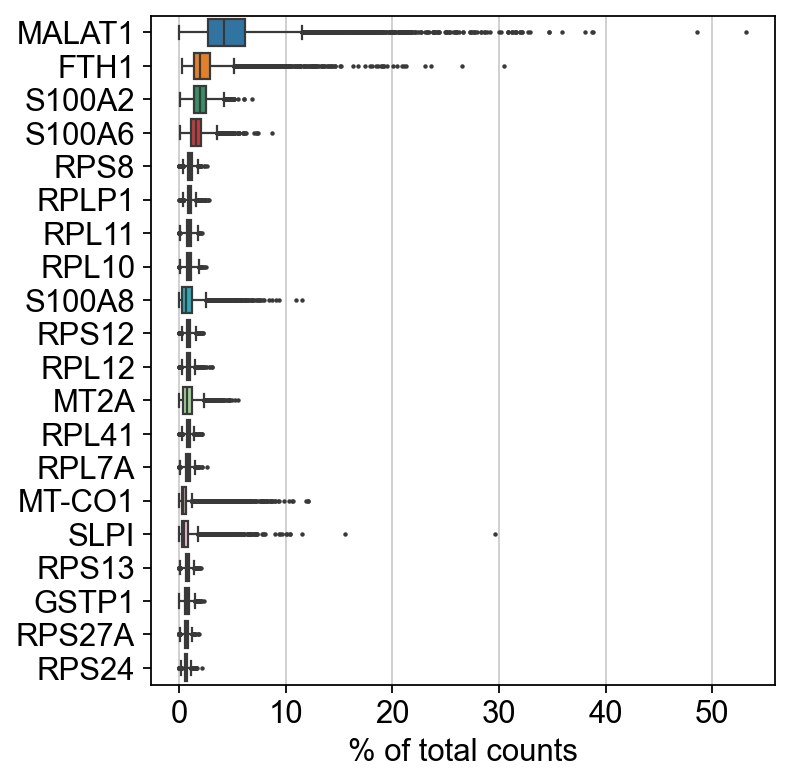

In [253]:
sc.pl.highest_expr_genes(adata, n_top=20)

## Quality Control (QC) and Cell Filtering

Perform QC analysis and filter cells based on user-defined criteria. Commonly used QC metrics include:

- The number of unique genes detected in each cell.
    - Low-quality cells or empty droplets typically have very few detected genes.
    - Cell doublets/multiplets may show an unusually high gene count.

- Total molecule count per cell
    - Strongly correlates with the number of unique genes and helps assess cell quality.

- Percentage of mitochondrial reads
    - High mitochondrial read content may indicate low-quality or dying cells.
    - Mitochondrial genes are identified as those starting with MT-.

Basic filtering:

- We filter cells that have unique feature counts less than 200.
- We filter genes that are detected in less than 3 cells.

We therefore now only filter cells with less than 200 genes expressed and genes that are detected in less than 1% of the cells.

In [254]:
sc.pp.filter_cells(adata, min_genes=200)

In [255]:
pct_genes_in_cell=round(len(adata.obs)*1/100,0)

In [256]:
sc.pp.filter_genes(adata, min_cells=pct_genes_in_cell)

filtered out 21791 genes that are detected in less than 63.0 cells


In [257]:
adata.obs

,n_genes
AAACCCACACATTCTT-1,3129
AAACCCACACGAAAGC-1,3282
AAACCCAGTCGTACTA-1,2728
AAACCCAGTCTGTCCT-1,1644
AAACCCATCGCTCTAC-1,3100
...,...
TTTGGTTTCGCTCATC-1,314
TTTGTTGAGAATTGTG-1,2008
TTTGTTGCACCCTGAG-1,3563
TTTGTTGCATGGTGGA-1,3375


In [258]:
adata.var

,gene_ids,feature_types,n_cells
AL669831.5,ENSG00000237491,Gene Expression,64
NOC2L,ENSG00000188976,Gene Expression,1043
KLHL17,ENSG00000187961,Gene Expression,107
HES4,ENSG00000188290,Gene Expression,1241
ISG15,ENSG00000187608,Gene Expression,432
...,...,...,...
MT-CYB,ENSG00000198727,Gene Expression,6098
MAFIP,ENSG00000274847,Gene Expression,88
AL592183.1,ENSG00000273748,Gene Expression,993
AC007325.4,ENSG00000278817,Gene Expression,658


We use the set of all genes starting with MT- as a set of mitochondrial genes.

In [259]:
# annotate the group of mitochondrial genes as "mt"
## mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")

In [260]:
adata.var

,gene_ids,feature_types,n_cells,mt
AL669831.5,ENSG00000237491,Gene Expression,64,False
NOC2L,ENSG00000188976,Gene Expression,1043,False
KLHL17,ENSG00000187961,Gene Expression,107,False
HES4,ENSG00000188290,Gene Expression,1241,False
ISG15,ENSG00000187608,Gene Expression,432,False
...,...,...,...,...
MT-CYB,ENSG00000198727,Gene Expression,6098,True
MAFIP,ENSG00000274847,Gene Expression,88,False
AL592183.1,ENSG00000273748,Gene Expression,993,False
AC007325.4,ENSG00000278817,Gene Expression,658,False


We then calculate the QC metrics.

In [261]:
sc.pp.calculate_qc_metrics(
                            adata,  qc_vars=["mt"], inplace=True
)

In [262]:
adata.var

,gene_ids,feature_types,n_cells,mt,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
AL669831.5,ENSG00000237491,Gene Expression,64,False,64,0.010101,0.010050,98.989899,64.0,4.174387
NOC2L,ENSG00000188976,Gene Expression,1043,False,1043,0.194129,0.177417,83.538510,1230.0,7.115582
KLHL17,ENSG00000187961,Gene Expression,107,False,107,0.017045,0.016902,98.311237,108.0,4.691348
HES4,ENSG00000188290,Gene Expression,1241,False,1241,0.448864,0.370780,80.413510,2844.0,7.953318
ISG15,ENSG00000187608,Gene Expression,432,False,432,0.079072,0.076101,93.181818,501.0,6.218600
...,...,...,...,...,...,...,...,...,...,...
MT-CYB,ENSG00000198727,Gene Expression,6098,True,6098,35.006470,3.583699,3.756313,221801.0,12.309541
MAFIP,ENSG00000274847,Gene Expression,88,False,88,0.013889,0.013793,98.611111,88.0,4.488636
AL592183.1,ENSG00000273748,Gene Expression,993,False,993,0.189552,0.173577,84.327652,1201.0,7.091742
AC007325.4,ENSG00000278817,Gene Expression,658,False,658,0.115688,0.109471,89.614899,733.0,6.598509


We can now inspect violin plots of some of the computed QC metrics:

- the number of genes expressed in the count matrix

- the total counts per cell

- the percentage of counts in mitochondrial genes

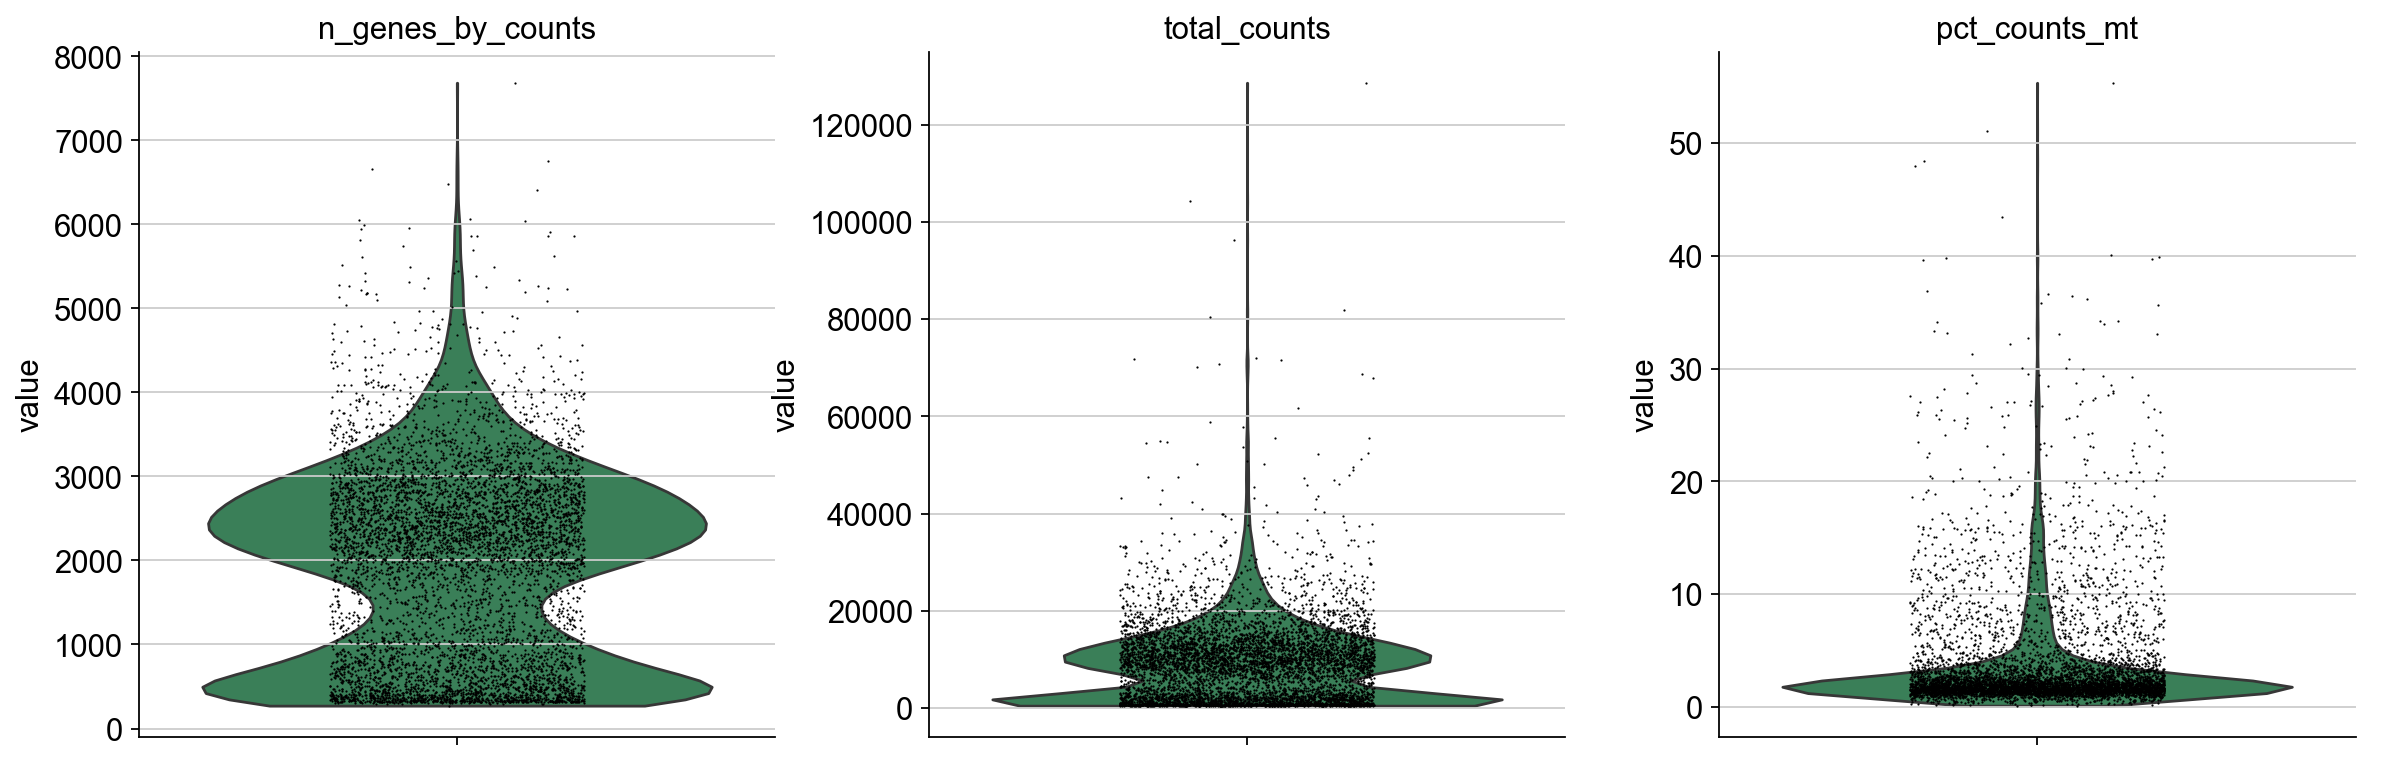

In [263]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    
    #density_norm='count',
    jitter=0.2,
    multi_panel=True,

    color='seagreen'
)

scanpy.pl.scatter() functions generate scatter plots to visualize quality control (QC) metrics.

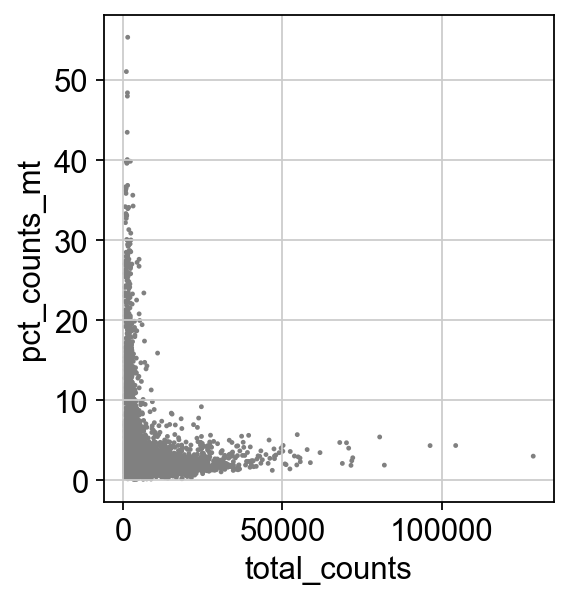

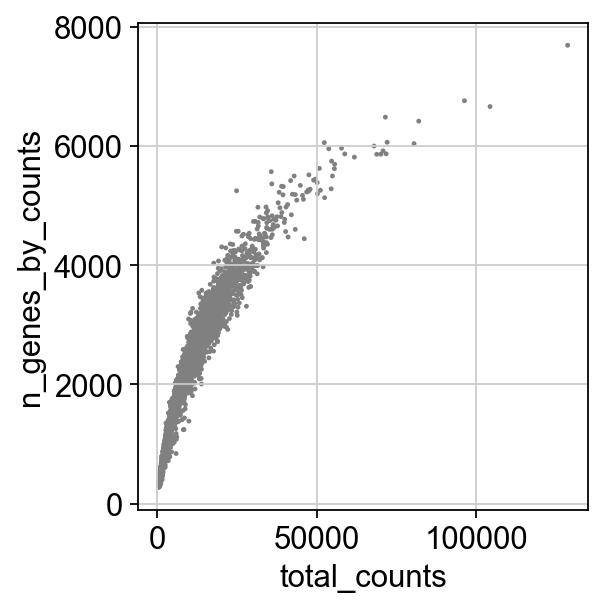

In [264]:
#scatter plots for QC metrics
sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt")
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts")

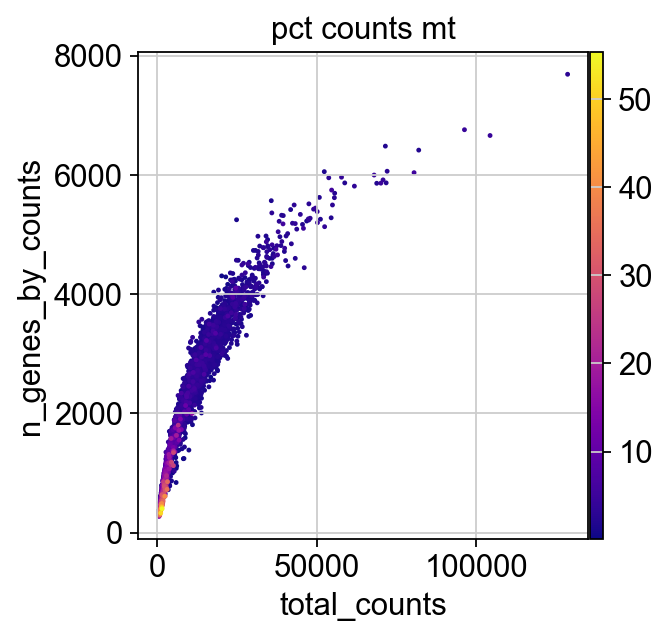

In [265]:
#Data quality summary plots
p1 = sc.pl.scatter(adata,  "total_counts", "n_genes_by_counts", color="pct_counts_mt")

Based on the QC metric plots, cells with high mitochondrial gene expression or abnormally high total counts can be filtered using manual or automatic thresholds. Rather than selecting arbitrary cutoffs, you can apply quantile-based filtering to set data-driven thresholds.

For genes total count:

In [266]:
# n_genes_by_counts
upper_lim=np.quantile(adata.obs.n_genes_by_counts.values, .98)
lower_lim=np.quantile(adata.obs.n_genes_by_counts.values, .02)
print(f'{lower_lim} to {upper_lim}')

322.0 to 4279.500000000001


In [267]:
# Filter cells based on the number of genes detected. Only keep cells where the number of genes
# detected is between the specified lower and upper limits (using quantiles or user-defined thresholds).
adata = adata[(adata.obs.n_genes_by_counts.values < upper_lim) & (adata.obs.n_genes_by_counts.values > lower_lim)]


We can do teh same with mt-genes: 

In [268]:
#pct_counts_mt
upper_lim_mt=np.quantile(adata.obs.pct_counts_mt.values, .98)
lower_lim_mt=np.quantile(adata.obs.pct_counts_mt.values, .02)
print(f'{lower_lim_mt} to {upper_lim_mt}')

0.6742075681686401 to 19.847311363220218


In [269]:
# Filter cells based on the percentage of mitochondrial gene counts.  
# Keep only cells where mitochondrial read percentage is within the specified lower and upper limits.  
adata = adata[(adata.obs.pct_counts_mt.values < upper_lim_mt) & (adata.obs.pct_counts_mt.values > lower_lim_mt)]


## Doublet detection
Next, we run a doublet detection algorithm, which is essential to prevent misclassifications and biases in downstream analysis. Scanpy provides Scrublet [Wolock et al., 2019], a method that identifies doublets using a nearest-neighbor classifier trained on both observed transcriptomes and simulated doublets.

In [270]:
sc.pp.scrublet(adata)

Running Scrublet
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
Embedding transcriptomes using PCA...
    using data matrix X directly
Automatically set threshold at doublet score = 0.47
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.5%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 3.8%
    Scrublet finished (0:00:19)


We can remove doublets by either filtering out the cells called as doublets, or waiting until we’ve done a clustering pass and filtering out any clusters with high doublet scores.

In [271]:
adata.obs

,n_genes,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,doublet_score,predicted_doublet
AAACCCACACATTCTT-1,3129,3076,8.031710,12001.0,9.392829,33.472211,43.504708,53.553871,67.677694,152.0,5.030438,1.266561,0.035941,False
AAACCCACACGAAAGC-1,3282,3248,8.086103,18852.0,9.844427,41.337789,53.256949,64.014428,76.575430,458.0,6.129050,2.429451,0.141243,False
AAACCCAGTCGTACTA-1,2728,2705,7.903227,11648.0,9.362976,36.195055,47.407280,58.464973,73.317308,129.0,4.867535,1.107486,0.031373,False
AAACCCAGTCTGTCCT-1,1644,1630,7.396949,5792.0,8.664406,49.412983,60.376381,68.922652,80.490331,716.0,6.575076,12.361878,0.038504,False
AAACCCATCGCTCTAC-1,3100,3077,8.032035,13704.0,9.525516,43.228255,53.903970,62.441623,73.394629,285.0,5.655992,2.079685,0.096174,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGTTTCGCAGATT-1,2365,2353,7.763871,9243.0,9.131730,38.407443,50.265065,60.889322,74.510440,125.0,4.836282,1.352375,0.218107,False
TTTGTTGAGAATTGTG-1,2008,1993,7.597898,7806.0,8.962776,40.456059,51.729439,62.323853,76.902383,111.0,4.718499,1.421983,0.125320,False
TTTGTTGCACCCTGAG-1,3563,3488,8.157370,17643.0,9.778152,41.370515,52.060307,62.126622,74.290087,317.0,5.762052,1.796747,0.053199,False
TTTGTTGCATGGTGGA-1,3375,3345,8.115521,15838.0,9.670231,37.290062,48.730900,58.845814,72.029297,223.0,5.411646,1.408006,0.079821,False


In [272]:
adata.obs[adata.obs.predicted_doublet==True]

,n_genes,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,doublet_score,predicted_doublet
GAGACCCGTATGGGAC-1,2902,2853,7.956477,13346.0,9.499047,40.116889,50.696838,60.617413,74.104601,180.0,5.198497,1.348719,0.497797,True


Only one doublet has been predicted. It will be reteined in the dataset.

## Normalization + Log-transformation

After removing unwanted cells from the dataset, the next step is to normalize the data. By default, we employ a global-scaling normalization method that normalizes the feature expression measurements for each cell by the total expression, multiplies this by a scale factor (10,000 by default).

In [273]:
sc.pp.normalize_total(adata, target_sum=1e4) #normalize every cell to 10000 UMI

normalizing counts per cell


    finished (0:00:00)


Log-transform the results:

In [274]:
sc.pp.log1p(adata) #change to log counts

## Feature selection: Identify highly-variable genes.

We next calculate a subset of features that exhibit high cell-to-cell variation in the dataset (i.e, they are highly expressed in some cells, and lowly expressed in others). We and others have found that focusing on these genes in downstream analysis helps to highlight biological signal in single-cell datasets.

In [275]:
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5) #default values

extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


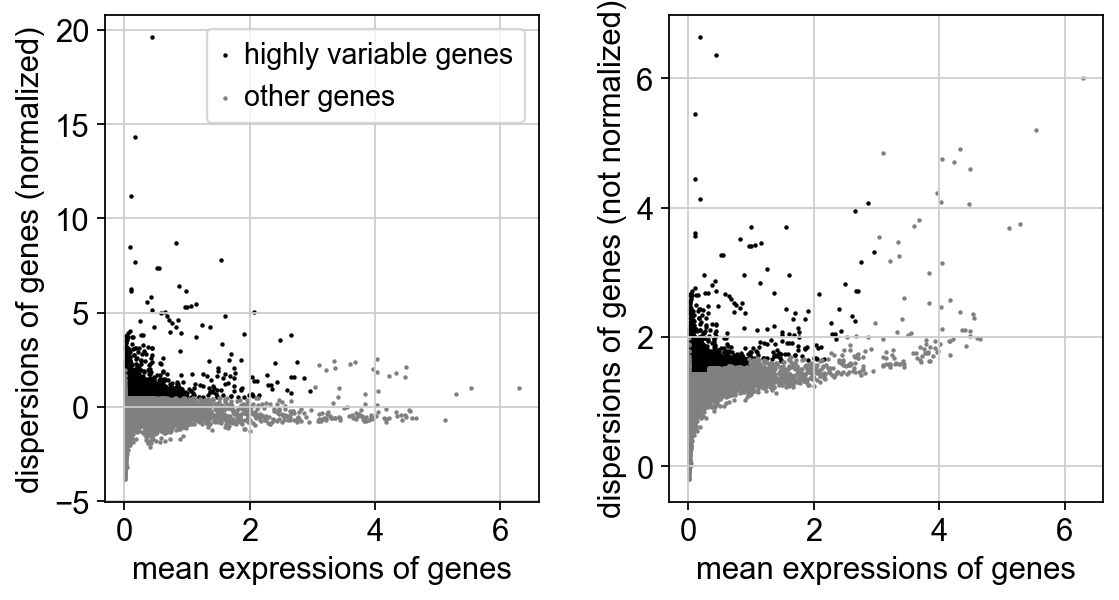

In [276]:
sc.pl.highly_variable_genes(adata)

In [277]:
adata.var['highly_variable'].value_counts()

False    8599
True     3148
Name: highly_variable, dtype: int64

Actually do the filtering:

In [278]:
adata = adata[:, adata.var.highly_variable]

## Scaling

Next, we apply a linear transformation (‘scaling’) that is a standard pre-processing step prior to dimensional reduction techniques like PCA. The sc.pp.scale() function:

- Shifts the expression of each gene, so that the mean expression across cells is 0
- Scales the expression of each gene, so that the variance across cells is 1
- This step gives equal weight in downstream analyses, so that highly-expressed genes do not dominate

Scale each gene to unit variance. Clip values exceeding standard deviation 10.

In [279]:
sc.pp.scale(adata, max_value=10)

... as `zero_center=True`, sparse input is densified and may lead to large memory consumption


# Principal component analysis - PCA

Reduce the dimensionality of the data by running principal component analysis (PCA), which reveals the main axes of variation and denoises the data.

In [280]:
sc.tl.pca(adata)

computing PCA
    with n_comps=50
    finished (0:00:01)


We can nowmake a scatter plot in the PCA coordinates:

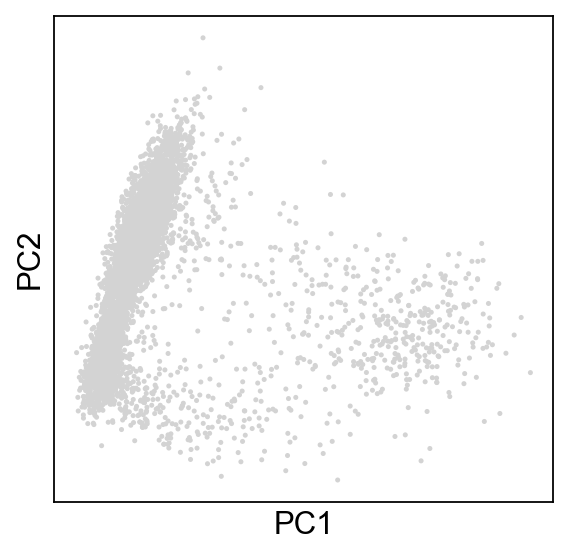

In [281]:
sc.pl.pca(adata)

Let us inspect the contribution of single PCs to the total variance in the data. This gives us information about how many PCs we should consider in order to compute the neighborhood relations of cells.

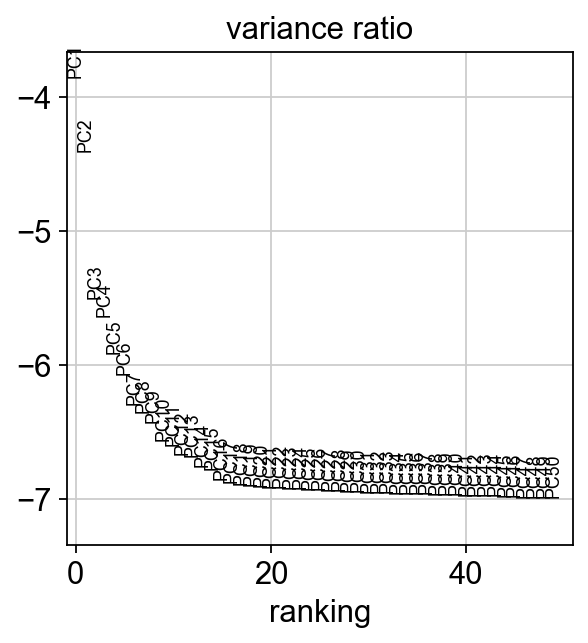

In [282]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True) 

We select n_pcs=50 for subsequent analysis to ensure that no important information is lost.

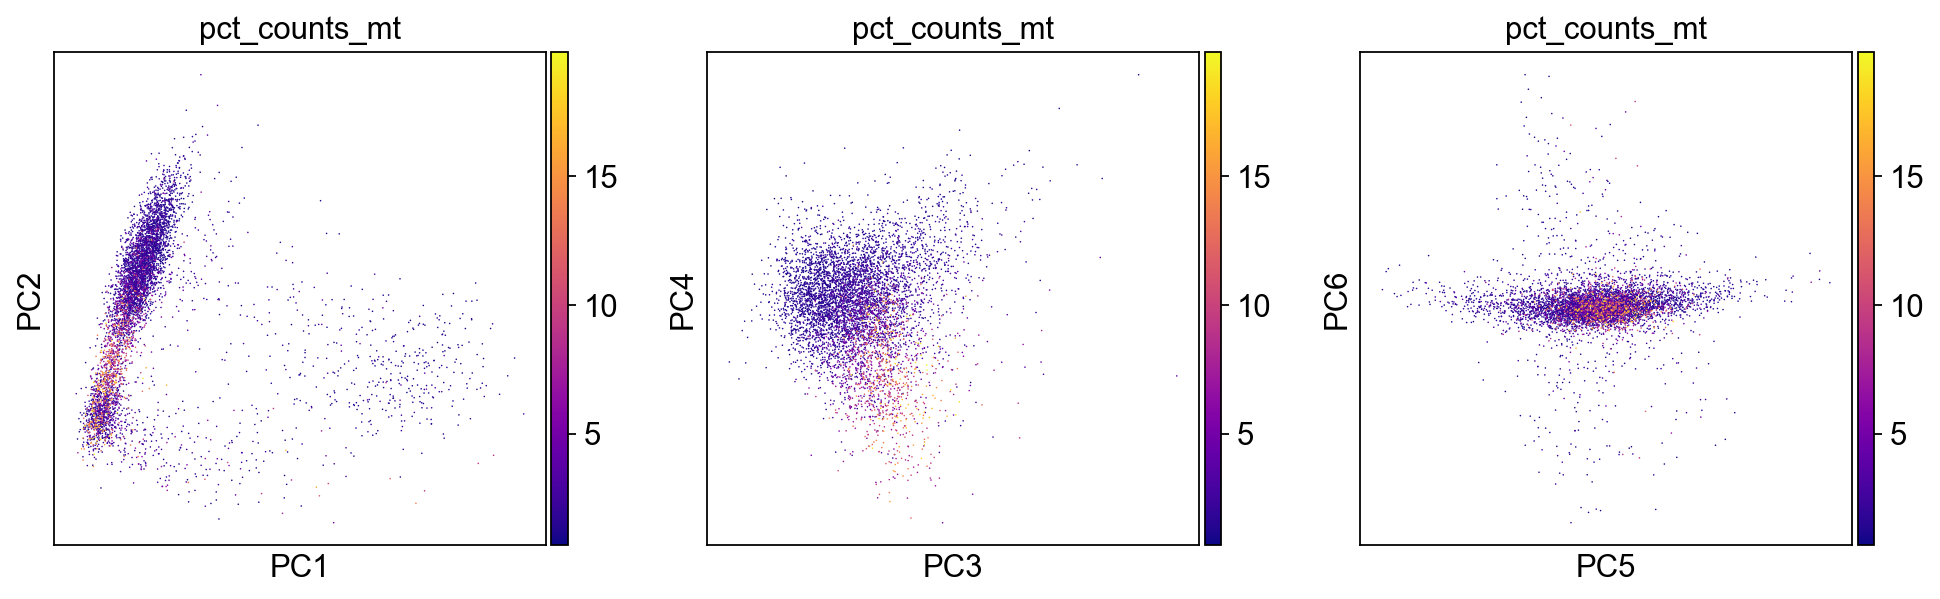

In [283]:
# Generate PCA plots with different combinations of principal components (PCs) to visualize the variation in the data.
# The plots are colored by the percentage of mitochondrial gene expression ("pct_counts_mt").
# Three different pairs of PCs (0-1, 2-3, and 4-5) are shown in separate columns.
# The `ncols=3` specifies 3 columns of plots, and `size=2` adjusts the size of each plot.
sc.pl.pca(
    adata,
    color=["pct_counts_mt", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (4, 5)],
    ncols=3,
    size=2,
)


Save the results in the Adata object containing the processed data matrix.

In [284]:
adata.write(results_file)

# Computing the neighborhood graph

Let us compute the neighborhood graph of cells using the PCA representation of the data matrix. 

- n_neighbors=10: This parameter sets the number of nearest neighbors to consider when constructing the neighborhood graph. Each cell will have its 10 closest neighbors based on the principal component analysis (PCA) space.

- n_pcs=50: This specifies the number of principal components to use for calculating the neighborhood distances. By using the first 50 principal components, you capture more variation in the data, improving the accuracy of the neighborhood graph.

This step is important for downstream analysis like clustering, trajectory inference, and visualization (e.g., UMAP or t-SNE), as it helps identify similar cells based on their gene expression profiles.

In [285]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=50)

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)


# Embedding the neighborhood graph - UMAP

UMAP (Uniform Manifold Approximation and Projection) is a non-linear dimensionality reduction technique used for visualizing complex datasets (McInnes et al., 2018). It aims to preserve the local structure of the data, meaning cells with similar gene expression profiles are placed near each other in low-dimensional space. This allows for effective clustering and visualization of cell groups.

While UMAP is a valuable tool for exploring data, it’s important to note that it does not always preserve global relationships, meaning it may not capture all underlying data complexity. 


In [286]:
sc.tl.umap(adata)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:09)


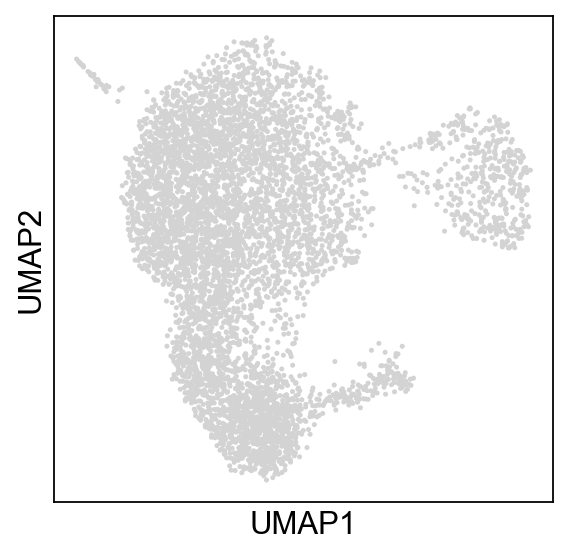

In [287]:
sc.pl.umap(adata)

# Clustering

Leiden clustering is an algorithm used to identify clusters within a graph (Traag et al. (2018)). It works by partitioning the graph in a way that maximizes modularity, meaning that cells within the same cluster are more similar to each other than to those in other clusters. 

## Leiden

We will determine the optimal clustering resolution by testing different values between 0.1 and 1, incrementing by 0.1. For each resolution, we will compute the clustering results and evaluate them using the silhouette score. The resolution that corresponds to the "elbow" of the silhouette score plot, where the score begins to plateau or decrease, will be chosen as the best balance between cluster cohesion and separation. This approach helps ensure that the selected resolution provides meaningful and distinct clusters for downstream analysis.

running Leiden clustering
    finished: found 4 clusters and added
    'leiden_res_0.1', the cluster labels (adata.obs, categorical) (0:00:00)


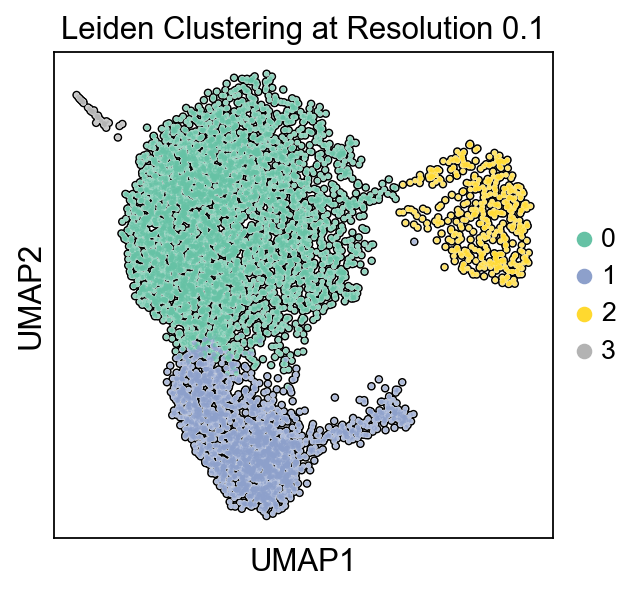

running Leiden clustering
    finished: found 4 clusters and added
    'leiden_res_0.2', the cluster labels (adata.obs, categorical) (0:00:00)


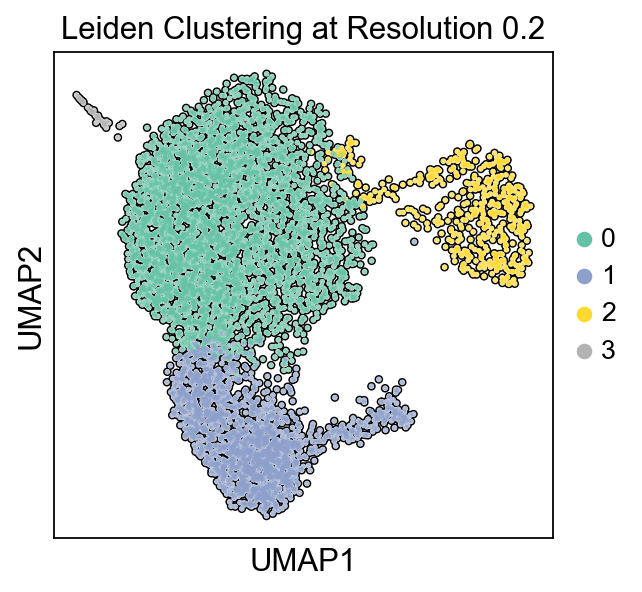

running Leiden clustering
    finished: found 6 clusters and added
    'leiden_res_0.3', the cluster labels (adata.obs, categorical) (0:00:00)


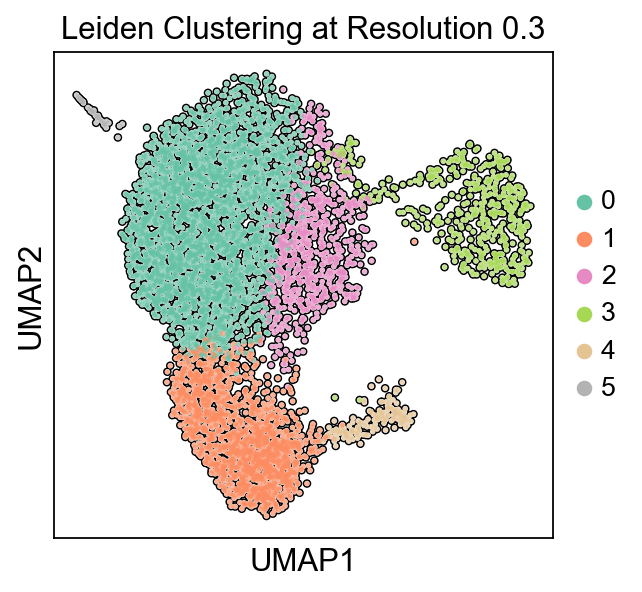

running Leiden clustering
    finished: found 7 clusters and added
    'leiden_res_0.5', the cluster labels (adata.obs, categorical) (0:00:00)


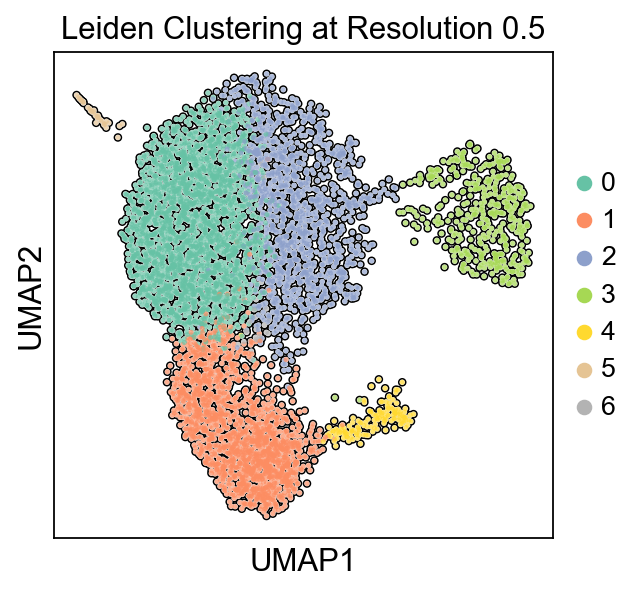

running Leiden clustering
    finished: found 7 clusters and added
    'leiden_res_0.6', the cluster labels (adata.obs, categorical) (0:00:00)


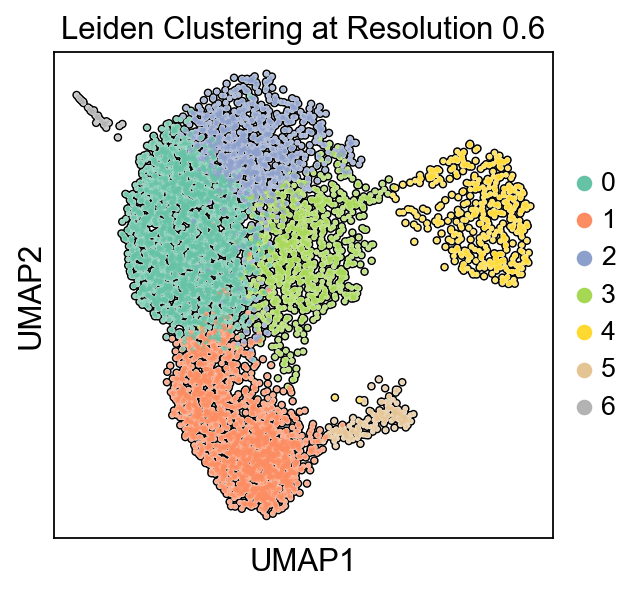

running Leiden clustering
    finished: found 8 clusters and added
    'leiden_res_0.7', the cluster labels (adata.obs, categorical) (0:00:00)


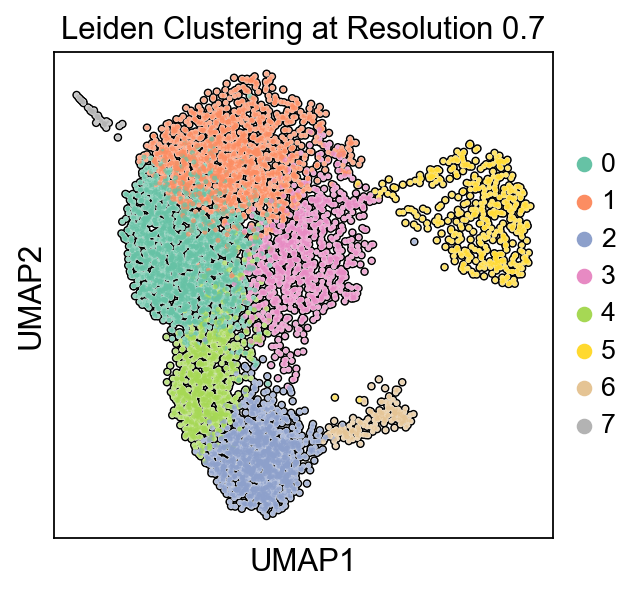

running Leiden clustering
    finished: found 9 clusters and added
    'leiden_res_0.8', the cluster labels (adata.obs, categorical) (0:00:00)


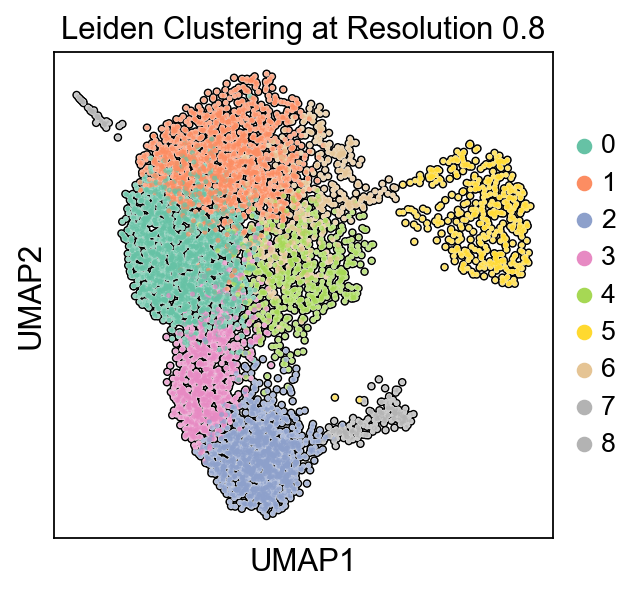

running Leiden clustering
    finished: found 10 clusters and added
    'leiden_res_0.9', the cluster labels (adata.obs, categorical) (0:00:00)


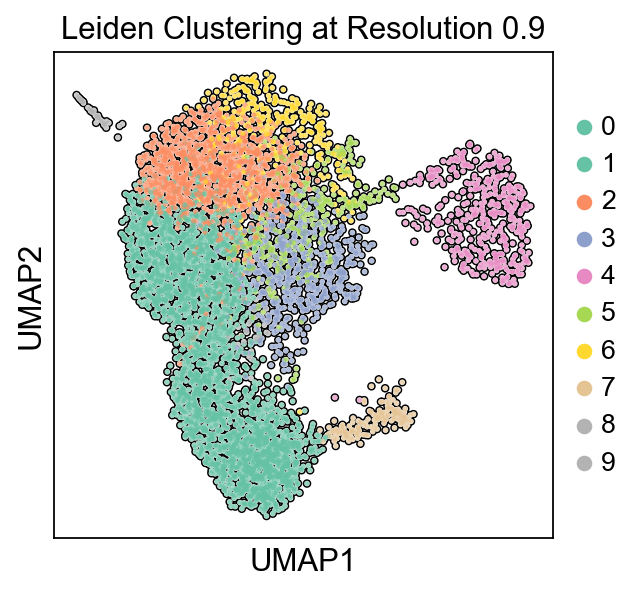

running Leiden clustering
    finished: found 11 clusters and added
    'leiden_res_1.0', the cluster labels (adata.obs, categorical) (0:00:00)


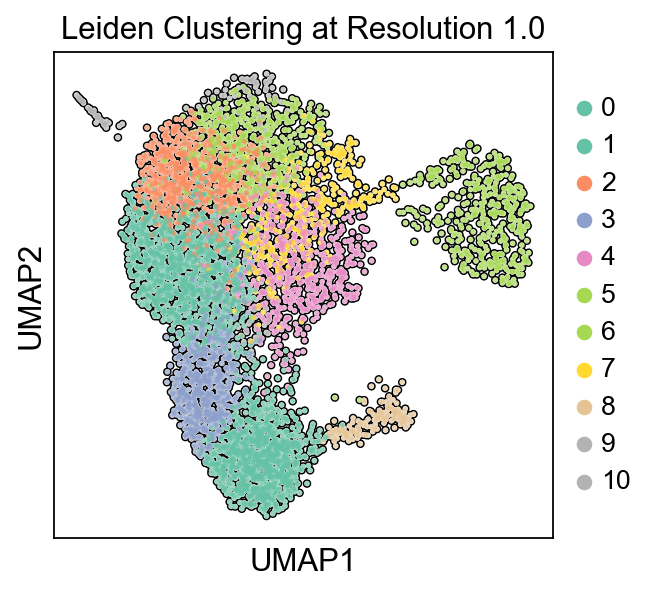

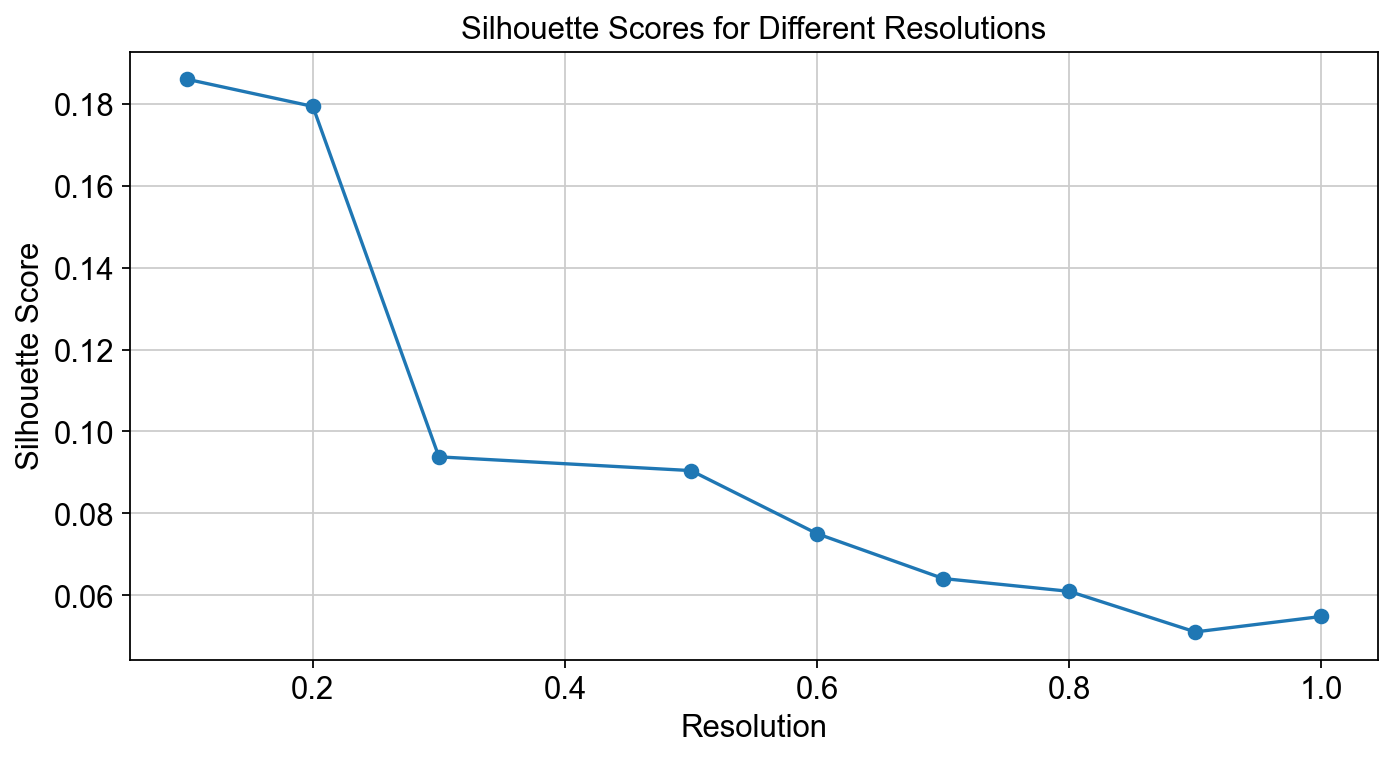

In [288]:
# Define the list of resolutions to test
resolutions = [0.1, 0.2, 0.3, 0.5,0.6, 0.7, 0.8, 0.9, 1.0]

# Dictionary to store silhouette scores
silhouette_scores = {}

for res in resolutions:
    # Perform Leiden clustering
    sc.tl.leiden(adata, resolution=res, key_added=f'leiden_res_{res}', random_state=0)
    
    # Calculate silhouette score
    labels = adata.obs[f'leiden_res_{res}']
    score = silhouette_score(adata.obsm['X_pca'], labels)
    silhouette_scores[res] = score
    
    # Plot UMAP with the current clustering
    sc.pl.umap(adata, 
               color=[f'leiden_res_{res}'], 
               add_outline=True,
               legend_fontsize=12,
               legend_fontoutline=2,
               title=f'Leiden Clustering at Resolution {res}',
               palette='Set2')

# Plot silhouette scores for different resolutions
plt.figure(figsize=(10, 5))
plt.plot(resolutions, [silhouette_scores[res] for res in resolutions], marker='o')
plt.xlabel('Resolution')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Different Resolutions')
plt.grid(True)
plt.show()

Based on the silhouette score analysis, we choose a resolution of 0.3. This resolution corresponds to the "elbow" of the silhouette score plot, where the score stabilizes, indicating a good balance between cluster cohesion and separation. As a result, 0.3 provides meaningful and distinct clusters for further analysis.

In [289]:
adata.obs

,n_genes,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,...,predicted_doublet,leiden_res_0.1,leiden_res_0.2,leiden_res_0.3,leiden_res_0.5,leiden_res_0.6,leiden_res_0.7,leiden_res_0.8,leiden_res_0.9,leiden_res_1.0
AAACCCACACATTCTT-1,3129,3076,8.031710,12001.0,9.392829,33.472211,43.504708,53.553871,67.677694,152.0,...,False,2,2,3,3,4,5,5,4,6
AAACCCACACGAAAGC-1,3282,3248,8.086103,18852.0,9.844427,41.337789,53.256949,64.014428,76.575430,458.0,...,False,0,0,2,2,3,3,6,5,7
AAACCCAGTCGTACTA-1,2728,2705,7.903227,11648.0,9.362976,36.195055,47.407280,58.464973,73.317308,129.0,...,False,0,0,2,2,2,1,6,6,5
AAACCCAGTCTGTCCT-1,1644,1630,7.396949,5792.0,8.664406,49.412983,60.376381,68.922652,80.490331,716.0,...,False,0,0,0,1,1,4,3,0,3
AAACCCATCGCTCTAC-1,3100,3077,8.032035,13704.0,9.525516,43.228255,53.903970,62.441623,73.394629,285.0,...,False,0,0,0,2,2,1,1,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGTTTCGCAGATT-1,2365,2353,7.763871,9243.0,9.131730,38.407443,50.265065,60.889322,74.510440,125.0,...,False,0,0,0,0,3,3,4,3,4
TTTGTTGAGAATTGTG-1,2008,1993,7.597898,7806.0,8.962776,40.456059,51.729439,62.323853,76.902383,111.0,...,False,0,0,0,0,0,0,0,1,0
TTTGTTGCACCCTGAG-1,3563,3488,8.157370,17643.0,9.778152,41.370515,52.060307,62.126622,74.290087,317.0,...,False,0,2,3,2,3,5,6,5,7
TTTGTTGCATGGTGGA-1,3375,3345,8.115521,15838.0,9.670231,37.290062,48.730900,58.845814,72.029297,223.0,...,False,0,0,0,0,0,1,1,2,2


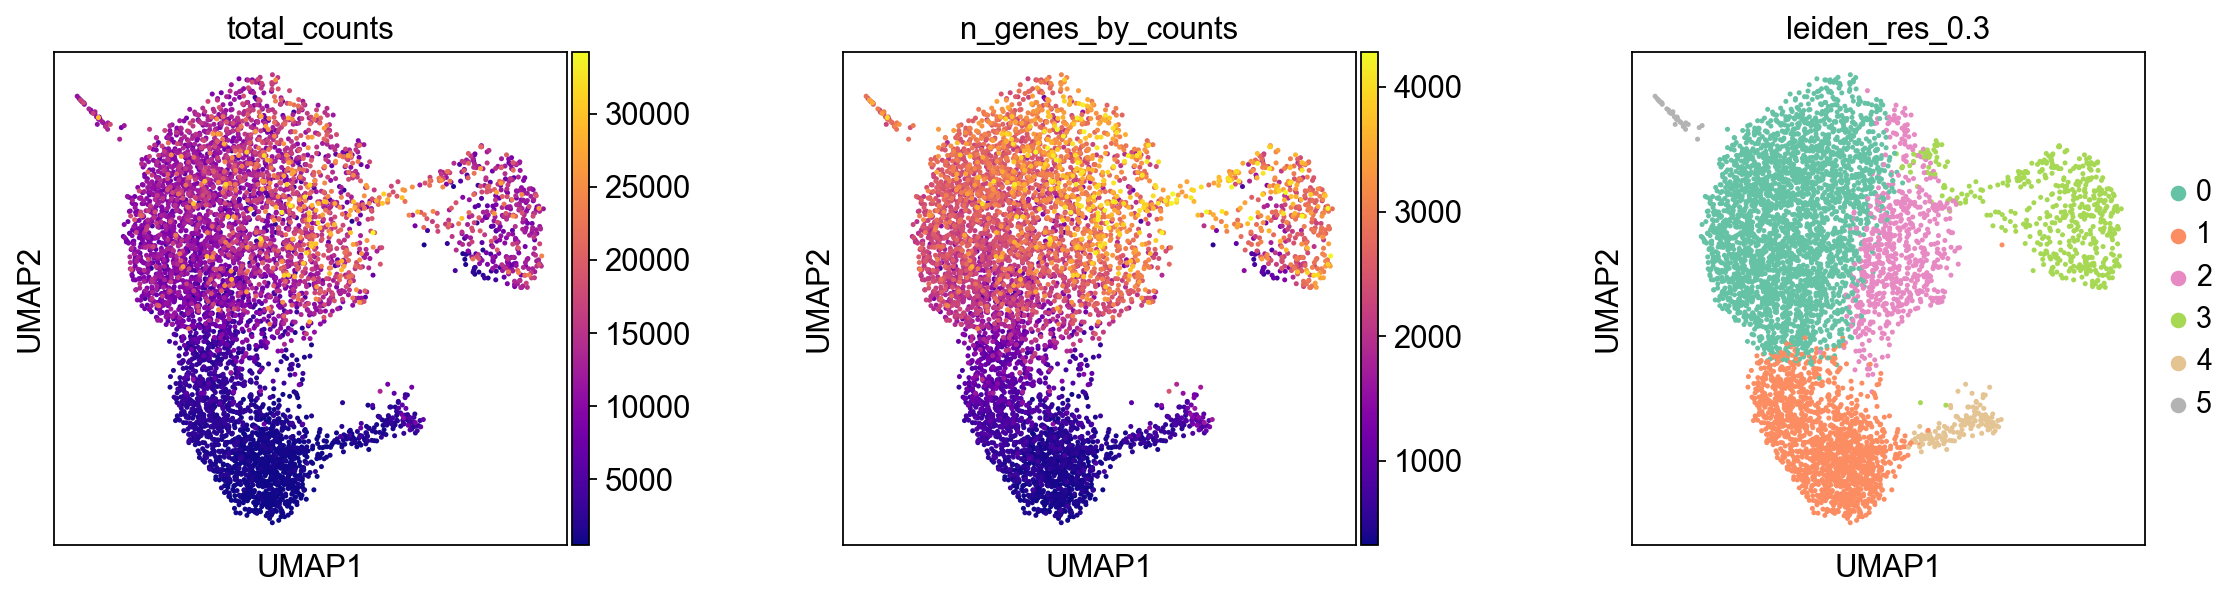

In [290]:
# Set the default figure size for all subsequent matplotlib plots to 4 inches by 4 inches
plt.rcParams["figure.figsize"] = (4, 4)

# Create a UMAP plot of the 'adata' object, coloring by 'total_counts', 'n_genes_by_counts', and 'leiden_res_0.3'
# 'total_counts' and 'n_genes_by_counts' show gene expression and cell complexity
# 'leiden_res_0.3' represents the Leiden clustering result at resolution 0.3
# 'wspace=0.4' sets the horizontal spacing between any subplots (if there are multiple plots)
sc.pl.umap(adata, color=["total_counts", "n_genes_by_counts", "leiden_res_0.3"], wspace=0.4)


In [291]:
#Save the result.
adata.write(results_file)

# Finding marker genes

We now differential gene expression (DEG) analysis to identify genes that are differentially expressed across clusters obtained from the Leiden clustering (at resolution 0.3). The sc.tl.rank_genes_groups function uses the Wilcoxon rank-sum test to compare gene expression between different groups (clusters) identified by the Leiden algorithm. This test is non-parametric and robust, especially for small datasets or datasets with non-normal distributions. After computing the rankings, sc.pl.rank_genes_groups is used to visualize the top 25 genes that are most differentially expressed in each cluster. 

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:02)


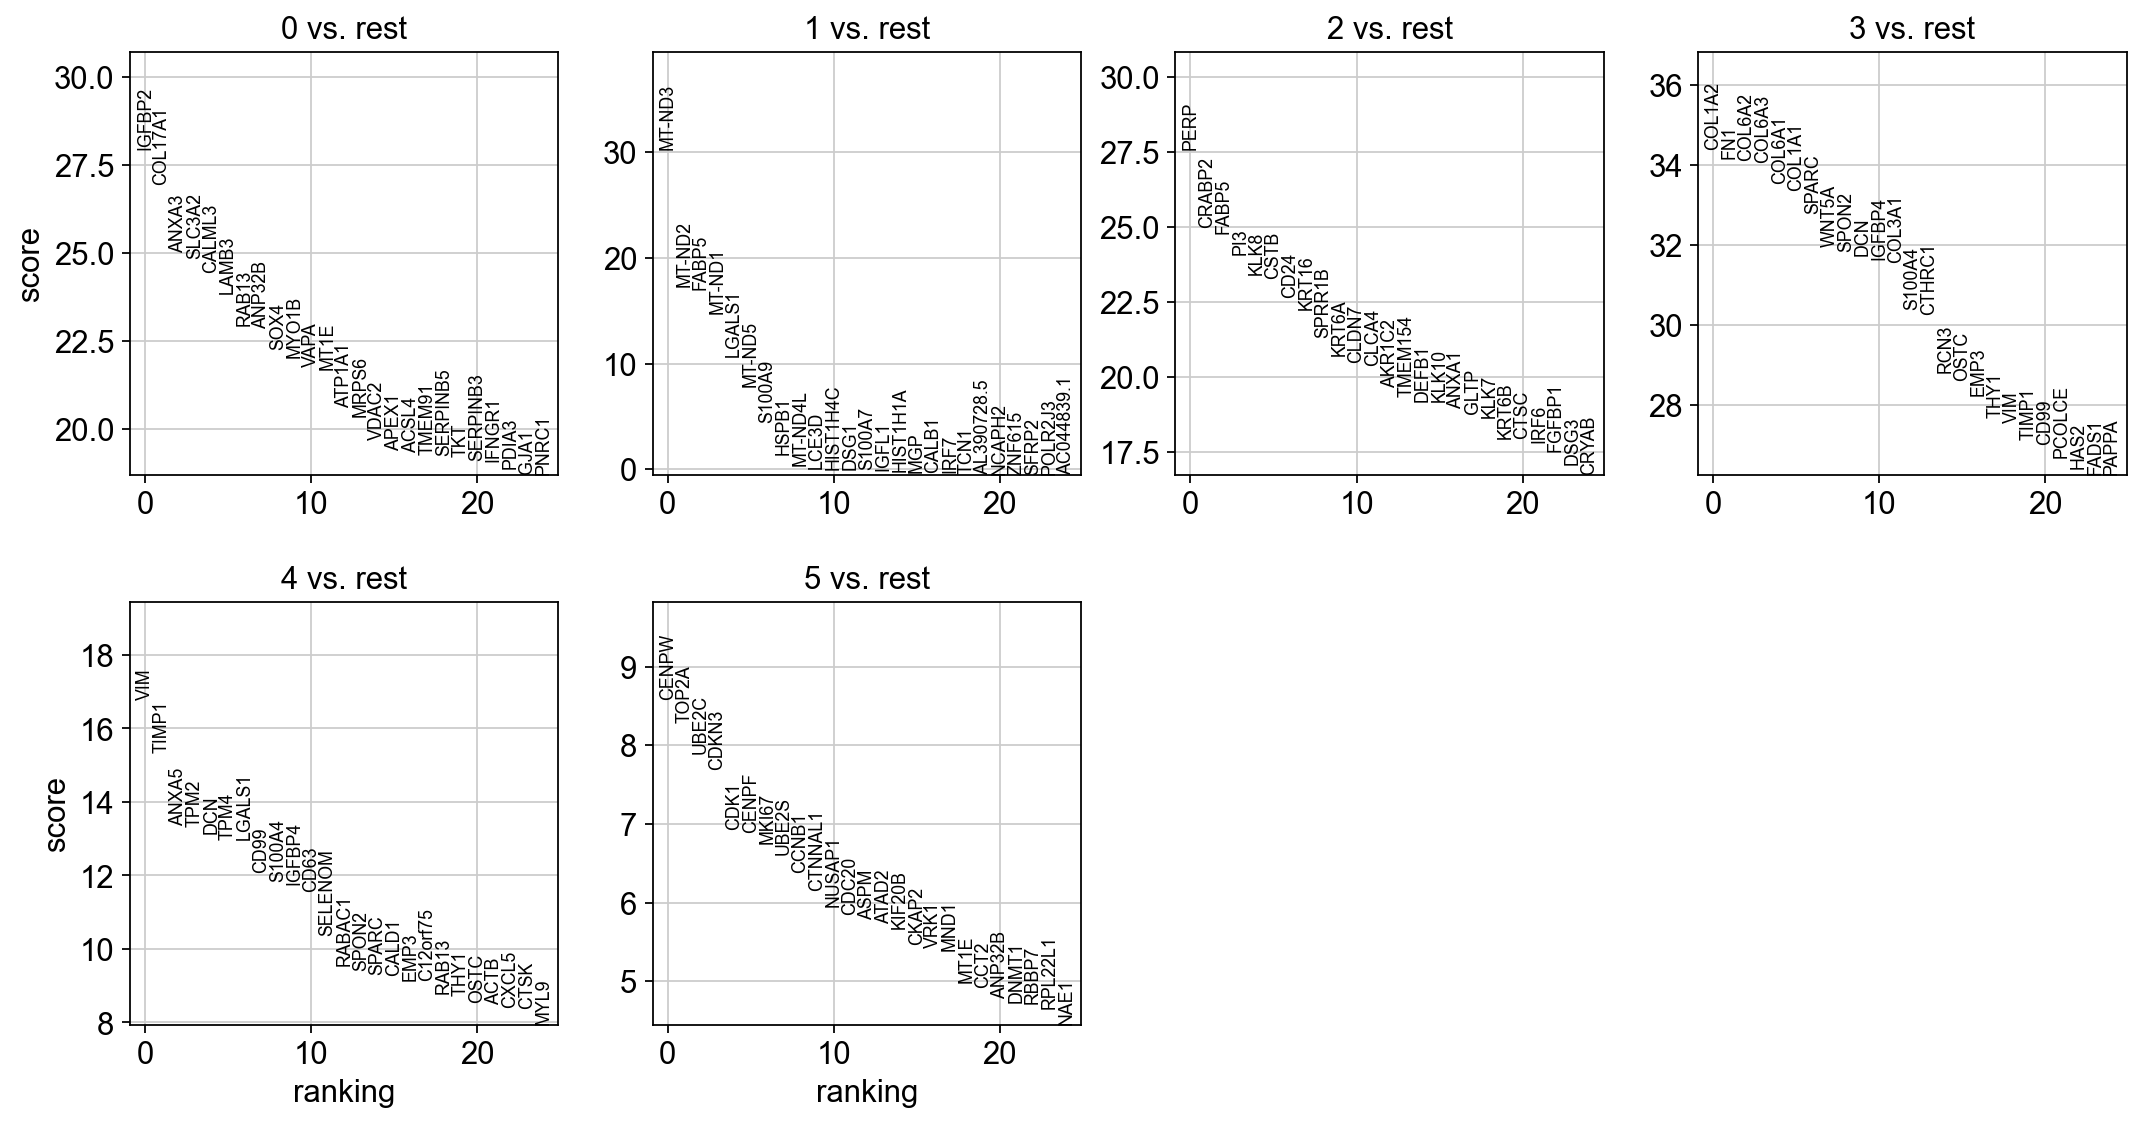

In [292]:
# Perform differential gene expression analysis to find the top genes distinguishing clusters (Leiden clustering at resolution 0.3)
# The 'wilcoxon' method is used for the statistical test, comparing each cluster against all others
sc.tl.rank_genes_groups(adata, "leiden_res_0.3", method="wilcoxon")

# Plot the top 25 genes for each cluster based on the differential expression results
# 'sharey=False' ensures each cluster gets its own y-axis for better visualization of gene expression differences
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)


# Save the processed adata object

We now extract and organize the results of the differential gene expression analysis performed earlier (via rank_genes_groups) into a a pandas DataFrame, where each column represents a specific piece of information (such as the gene names, log fold changes, etc.) for each cluster. The DataFrame is saved as a CSV file.

In [295]:
# Extract the differential gene expression analysis results from adata.uns["rank_genes_groups"]
# 'names', 'logfoldchanges', 'scores', and 'pvals_adj' are the keys containing information about differentially expressed genes
result = adata.uns["rank_genes_groups"]

# Get the list of cluster groups
groups = result["names"].dtype.names

# Organize the extracted data into a pandas DataFrame
# The DataFrame will have columns for each cluster group, with gene names, log fold changes, scores, and adjusted p-values
data = pd.DataFrame({group + '_' + key[:1]: result[key][group] for group in groups for key in ['names', 'logfoldchanges', 'scores', 'pvals_adj']})

# Save the organized data to a CSV file for later analysis
data.to_csv("scanpy_result_scRNAseqDBC.csv")

In [191]:
adata.write(results_file)